In [1]:
from src.mini_latents.pca import PCA
from src.mini_latents.ppca_fa import pPCA, FA

import inspect
import time
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nbformat
%matplotlib inline


In [2]:
data_path = 'data/ps8_data.mat'
data = scipy.io.loadmat(data_path)

Xplan = data['Xplan']
Xsim  = data['Xsim']

print(f"Xplan shape: {Xplan.shape}")
print(f"Xsim shape: {Xsim.shape}")

Xplan shape: (728, 97)
Xsim shape: (8, 2)


# Q1

In [3]:
pca = PCA(n_components=8)
pca.fit(Xplan)
Xplan_pca_transformed = pca.transform(Xplan)

exp_var = pca.explained_variance_.astype(np.float64) * (len(Xplan) - 1)
acc_var = np.cumsum(exp_var)

total_var = np.sum(np.var(Xplan, axis=0, ddof=1)) * (len(Xplan) - 1)   # true total variance, same units as exp_var
explained_var_percentage = (acc_var[2] / total_var) * 100
print(f"The top 3 principal components explain {explained_var_percentage:.3f}% of all variance")

The top 3 principal components explain 44.729% of all variance


## (a)

Looking at the plot below, we see a steep dropoff after the 3rd principal component. The top 3 principal components captures 44.8% of the total variance


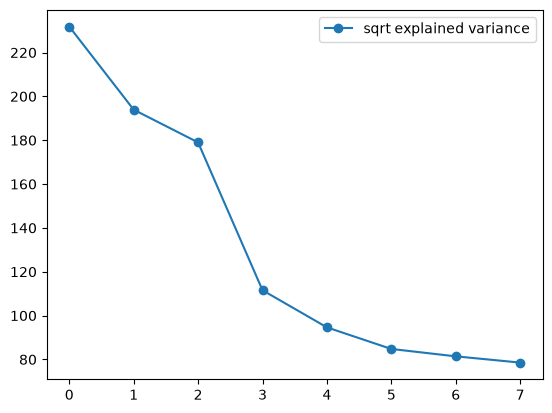

In [4]:
fig, ax = plt.subplots()

sqrt_exp_var = np.sqrt(exp_var)
line1, = ax.plot(sqrt_exp_var, marker='o', label='sqrt explained variance')
ax.legend()
plt.show()
plt.close('all')

## (b)

In [5]:
Z_8d = pca.transform(X = Xplan)
Z_3d = Z_8d[:, :3]
Z_3d.shape

(728, 3)

In [6]:
import plotly.express as px

In [7]:
# 8 reach angles with 91 trials each
num_reaches_per_angle = 91
angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]

# Generate categorical labels corresponding to the 8 blocks
reach_labels = [
    f"Angle {i+1} ({angles_deg[i]}°)" 
    for i in range(8) 
    for _ in range(num_reaches_per_angle)
]

# 3. Create DataFrame
df = pd.DataFrame({
    'PC1': Z_3d[:, 0],
    'PC2': Z_3d[:, 1],
    'PC3': Z_3d[:, 2],
    'Reach Direction': reach_labels
})

# 4. Plotly 3D Scatter Plot
fig = px.scatter_3d(
    df, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Reach Direction',
    title='Reach data projected into three-dimensional PC space'
)

# 5. Fine-tune marker style for visibility
fig.update_traces(marker=dict(size=4, opacity=0.85, line=dict(width=0.5, color='black')))

# Format axes and font size to match MATLAB
fig.update_layout(
    scene=dict(
        xaxis_title='PC 1',
        yaxis_title='PC 2',
        zaxis_title='PC 3'
    ),
    title_font_size=16
)

fig.show(renderer='browser') 

![Q1b Plot](q1b.png)

## (c)

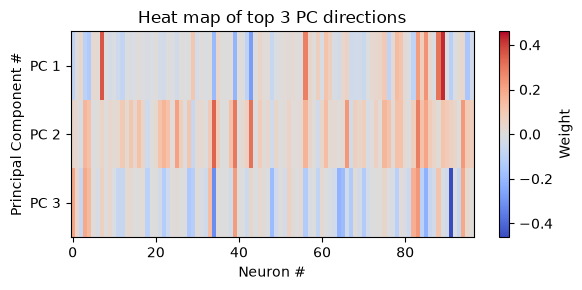

In [8]:
U_M = pca.components_[:, :3].T   # shape (3, 97): PC 1-3 as rows, neurons as columns

plt.figure(figsize=(6, 3))
plt.xlabel('Neuron #')
plt.ylabel('Principal Component #')
plt.title('Heat map of top 3 PC directions')

max_val = np.max(np.abs(U_M))
plt.imshow(U_M, aspect='auto', cmap='coolwarm', vmin=-max_val, vmax=max_val)

plt.yticks([0, 1, 2], ['PC 1', 'PC 2', 'PC 3'])  
plt.colorbar(label='Weight')
plt.tight_layout()
plt.show()

# Q2

## (a)

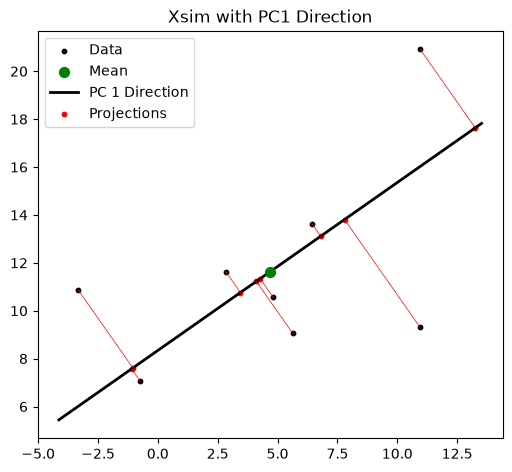

In [9]:
pca = PCA(n_components=1)
pca.fit(Xsim)
x, y = pca.components_[0, 0], pca.components_[1, 0]   # fixed: two rows, one column

Xsim_mean = Xsim.mean(axis=0)
scale = np.sqrt(pca.explained_variance_[0]) * 2

plt.figure(figsize=(6, 6))
plt.scatter(Xsim[:, 0], Xsim[:, 1], color='black', s=10, label='Data')
plt.scatter(Xsim_mean[0], Xsim_mean[1], color='green', s=50, zorder=5, label='Mean')
plt.plot(
    [Xsim_mean[0] - scale * x, Xsim_mean[0] + scale * x],
    [Xsim_mean[1] - scale * y, Xsim_mean[1] + scale * y],
    color='black', linewidth=2, label='PC 1 Direction'
)

Z = pca.transform(Xsim)
X_projected = Xsim_mean + Z @ pca.components_.T   # fixed: (1,2), not (1,1)
x_coords = X_projected[:, 0]
y_coords = X_projected[:, 1]
plt.scatter(x_coords, y_coords, color='red', s=10, label='Projections')

for i in range(Xsim.shape[0]):
    plt.plot([Xsim[i, 0], x_coords[i]], [Xsim[i, 1], y_coords[i]], color='red', linewidth=0.5)

plt.title('Xsim with PC1 Direction')
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

## (b)

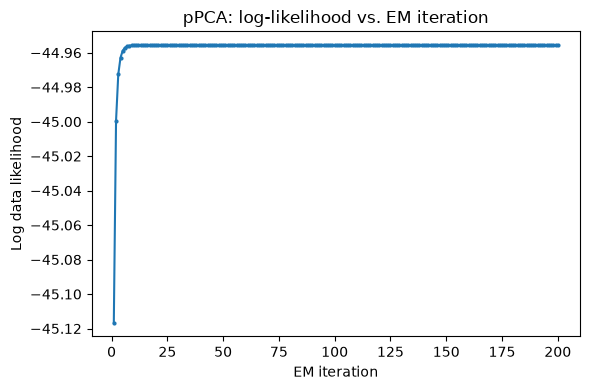

Monotonic non-decreasing: True


In [10]:
from src.mini_latents.ppca_fa import pPCA

ppca = pPCA(n_components=1)
ppca.fit(Xsim, max_iter=200, tol=-1)  # tol=-1 disables early stop so you see the full plateau

ll_history = np.array(ppca.ll_history_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(ll_history) + 1), ll_history, marker='o', markersize=2)
plt.xlabel('EM iteration')
plt.ylabel('Log data likelihood')
plt.title('pPCA: log-likelihood vs. EM iteration')
plt.tight_layout()
plt.show()

print('Monotonic non-decreasing:', np.all(np.diff(ll_history) >= -1e-9))

## (c)

In [11]:
# ---- 2(c): PPCA covariance vs sample covariance ----
W = ppca.components_                       # (2, 1)
sigma2 = ppca.noise_model.psi               # scalar
C_ppca = W @ W.T + sigma2 * np.eye(2)

sample_cov = np.cov(Xsim, rowvar=False, ddof=0)   # ddof=0 to match EM's implicit population convention

print("PPCA covariance (W W^T + sigma^2 I):\n", C_ppca)
print("\nSample covariance:\n", sample_cov)

PPCA covariance (W W^T + sigma^2 I):
 [[22.43138488  9.43979111]
 [ 9.43979111 15.59221145]]

Sample covariance:
 [[22.43138488  9.43979111]
 [ 9.43979111 15.59221145]]


## (d)

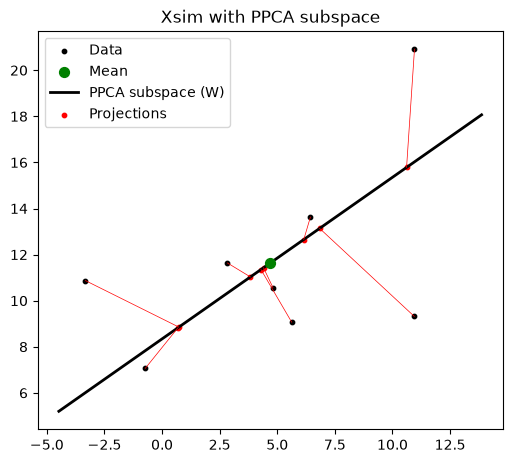

In [12]:
# ---- 2(d): PPCA visualization ----
w_vec = W[:, 0]
Xsim_mean = ppca.mean_
scale = np.sqrt(np.sum(w_vec**2)) * 2.5

plt.figure(figsize=(6, 6))
plt.scatter(Xsim[:, 0], Xsim[:, 1], color='black', s=10, label='Data')
plt.scatter(Xsim_mean[0], Xsim_mean[1], color='green', s=50, zorder=5, label='Mean')

# PC space line (through the mean, direction = W)
plt.plot(
    [Xsim_mean[0] - scale * w_vec[0]/np.linalg.norm(w_vec), Xsim_mean[0] + scale * w_vec[0]/np.linalg.norm(w_vec)],
    [Xsim_mean[1] - scale * w_vec[1]/np.linalg.norm(w_vec), Xsim_mean[1] + scale * w_vec[1]/np.linalg.norm(w_vec)],
    color='black', linewidth=2, label='PPCA subspace (W)'
)

# projections: x_hat_n = W E[z_n|x_n] + mean
Ez = ppca.transform(Xsim)                    # (8, 1)
X_projected = Xsim_mean + Ez @ W.T           # (8, 2)

plt.scatter(X_projected[:, 0], X_projected[:, 1], color='red', s=10, label='Projections')
for i in range(Xsim.shape[0]):
    plt.plot([Xsim[i, 0], X_projected[i, 0]], [Xsim[i, 1], X_projected[i, 1]], color='red', linewidth=0.5)

plt.title('Xsim with PPCA subspace')
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

PCA's projection is the orthogonal projection onto the subspace. pPCA's projection is the posterior mean E[z|x] = M⁻¹W^TΨ⁻¹x, a Bayesian shrinkage estimate that pulls points toward the prior mean (origin/z=0) by an amount controlled by σ². Since σ²>0 here, E[z|x] is a shrunk version of the orthogonal projection coordinate, so the connecting lines are no longer perpendicular. (As σ²→0, M⁻¹W^TΨ⁻¹→ the orthogonal projector and pPCA converges exactly to PCA, which is what direction-matching above already confirms holds for the subspace itself.)

## (e)

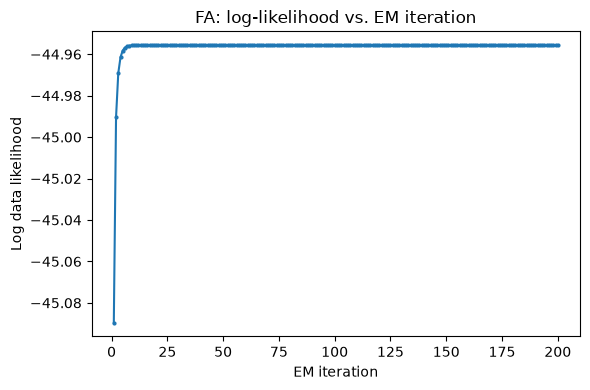

Monotonic non-decreasing: True


In [13]:
# ---- 2(e): EM for FA, log-likelihood trajectory ----
from src.mini_latents.ppca_fa import FA

fa = FA(n_components=1)
fa.fit(Xsim, max_iter=200, tol=-1)

ll_history_fa = np.array(fa.ll_history_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(ll_history_fa) + 1), ll_history_fa, marker='o', markersize=2)
plt.xlabel('EM iteration')
plt.ylabel('Log data likelihood')
plt.title('FA: log-likelihood vs. EM iteration')
plt.tight_layout()
plt.show()

print('Monotonic non-decreasing:', np.all(np.diff(ll_history_fa) >= -1e-9))

## (f)

In [14]:
# ---- 2(f): FA covariance vs sample covariance ----
W_fa = fa.components_                        # (2, 1)
Psi_fa = fa.noise_model.psi                  # (2,) diagonal, per-dimension
C_fa = W_fa @ W_fa.T + np.diag(Psi_fa)

sample_cov = np.cov(Xsim, rowvar=False, ddof=0)

print("FA covariance (W W^T + Psi):\n", C_fa)
print("\nSample covariance:\n", sample_cov)

FA covariance (W W^T + Psi):
 [[22.43138488  9.43979111]
 [ 9.43979111 15.59221145]]

Sample covariance:
 [[22.43138488  9.43979111]
 [ 9.43979111 15.59221145]]


## (g)

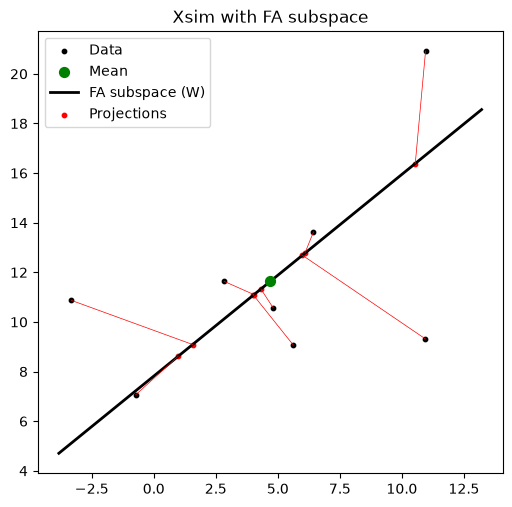

In [15]:
# ---- 2(g): FA visualization ----
w_vec = W_fa[:, 0]
Xsim_mean = fa.mean_
scale = np.sqrt(np.sum(w_vec**2)) * 2.5
w_hat = w_vec / np.linalg.norm(w_vec)

plt.figure(figsize=(6, 6))
plt.scatter(Xsim[:, 0], Xsim[:, 1], color='black', s=10, label='Data')
plt.scatter(Xsim_mean[0], Xsim_mean[1], color='green', s=50, zorder=5, label='Mean')

plt.plot(
    [Xsim_mean[0] - scale * w_hat[0], Xsim_mean[0] + scale * w_hat[0]],
    [Xsim_mean[1] - scale * w_hat[1], Xsim_mean[1] + scale * w_hat[1]],
    color='black', linewidth=2, label='FA subspace (W)'
)

Ez_fa = fa.transform(Xsim)
X_projected_fa = Xsim_mean + Ez_fa @ W_fa.T

plt.scatter(X_projected_fa[:, 0], X_projected_fa[:, 1], color='red', s=10, label='Projections')
for i in range(Xsim.shape[0]):
    plt.plot([Xsim[i, 0], X_projected_fa[i, 0]], [Xsim[i, 1], X_projected_fa[i, 1]], color='red', linewidth=0.5)

plt.title('Xsim with FA subspace')
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

Not the same graph because FA allows different noise variance for each dimension.